In [1]:
from trajectories import *
from jax_signatures.signature import * 
from jax_signatures.exact_representations import * 
from jax_signatures.ode_solver import * 
from schemes import * 
from utils import *

from matplotlib.ticker import FuncFormatter
import time 

## I. Illustration of the convergence $\widehat{\mathcal E}_h^{\boldsymbol{\lambda}} \xrightarrow[h\to\infty]{} \widehat{\mathcal E}^{\boldsymbol{\lambda}}$ 

It is clear that $\mathbb{E}[\widehat{\mathbb{W}}_t^{\boldsymbol{\lambda}}]= \mathbb{E}[\widehat{\mathbb{W}}_0^{\boldsymbol{\lambda}}] := \widehat{\mathcal E}^{\boldsymbol{\lambda}}$ such that 
\begin{align*}
 \widehat{\mathcal E}^{\boldsymbol{\lambda}} = \left(1, \frac{1}{\lambda^1}, 0, \frac{1}{2(\lambda^1)^2}, 0, 0, \frac{1}{4\lambda^2}, \ldots\right).
\end{align*}

In [2]:
M = 2 
lambd = jnp.array([1, 3])
h_values = np.linspace(0, 6, 500)
values = []
for h in h_values : 
    values.append(expected_bm_EFM_signature(M=M, lambd=lambd, t=h))
stationary = expected_bm_EFM_signature(M=M, lambd=lambd, n_points=100)

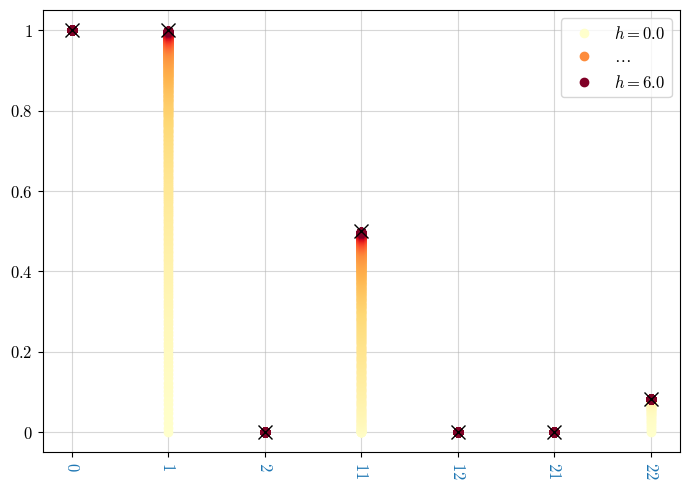

In [3]:
cmap = plt.get_cmap("YlOrRd", len(h_values))
norm_ = mcolors.Normalize(vmin=h_values.min(), vmax=h_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm_)
sm.set_array([])

fig, ax = plt.subplots(figsize=(7,5))
for i, h in enumerate(h_values) : 
    color = cmap(norm_(h))
    if i == 0 or i == len(h_values)-1 : 
        values[i].plot(ax=ax, color=color, label=fr"$h={np.round(h, 2)}$")
    elif i == len(h_values)//2 : 
        values[i].plot(ax=ax, color=color, label=fr"$\ldots$")
    else : 
        values[i].plot(ax=ax, color=color)
stationary.plot(ax=ax, color="black", marker="x", markersize=10)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## II. Moments of an Ornstein-Uhlenbeck process (Explicit + Markovian)

Recall that $dU_t = \mu(\theta-U_t)\, dt + \eta\, dW_t,\, U_0 = x$ can be rewritten as 
$$U_t = \theta + (x-\theta) e^{-\mu t} + \eta \int_0^t e^{-\mu(t-s)}\, dW_s \sim \mathcal N(\mu_t, \sigma_t^2), \quad \mu_t := \theta + (x-\theta)e^{-\mu t},\quad \sigma_t^2 := \frac{\eta^2}{2\mu}(1-e^{-2\mu t}).$$
In particular, 
\begin{align*}
\mathbb E[U_t] = \mu_t, \quad \mathbb E[U_t^2] = \mu_t^2 + \sigma^2, \quad \mathbb E[U_t^3] = \mu_t^3 + 3\mu_t\sigma_t^2, \quad \mathbb E[U_t^4] = \mu_t^4 + 6\mu_t^2\sigma_t^2 + 3\sigma_t^4.
\end{align*}
The conditional moments are explicit too, by using the fact that 
\begin{align*}
U_T | U_t \sim\mathcal N\left(\theta + (U_t - \theta) e^{-\mu(T-t)}, \frac{\eta^2}{2\mu}(1-e^{-2\mu(T-t)}\right). 
\end{align*}

### II.1. "Unconditional" moments 

In [4]:
T = 1
T0 = -1
n1 = 500 # coarser grid for the burn-in 
n2 = T * 365 * 5 + 1
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0)

mu, theta, eta = 5, 1.0, 1.5

X_true = simulate_Langevin_Euler(0.0, mu, theta, eta, paths)
x = X_true[0, len(t_burn)]
x

np.float64(0.7113987145410022)

In [5]:
k_grid, d = jnp.arange(1, 5), 2 

In [6]:
M_values = np.arange(1, 11) 
moments_sig = []
for M in tqdm(M_values) : 
    shuffle_table = get_shuffle_table(M, d)
    l = compute_l_OU(x, mu, theta, eta, M, d, shuffle_table)
    moments_sig.append(unconditional_moments(k_grid,  t_main,  M, l))
moments_sig = np.array(moments_sig)

100%|███████████████████████████████████████████| 10/10 [01:06<00:00,  6.65s/it]


In [7]:
lambd = jnp.array([5.0, 5.0])
M = 5
l = compute_l_EFM_OU(lambd, mu, theta, eta, M)
EFM_sig = compute_EFM_signature(paths, t_grid, lambd, M) 
moments_EFM_sig = unconditional_moments_EFM(k_grid, EFM_sig, t_main, lambd, M, l) 

In [8]:
mu_t = theta + (x-theta) * np.exp(-mu * t_main)
sigma_t_2 = 0.5 * eta**2 / mu *(1 - np.exp(-2 * mu * t_main))

In [9]:
idx_train = int(0.75 * 365 * 5 + 1) 
idx_val = idx_train = n2 
Y = X_true[0, len(t_burn):]

In [10]:
bounds = [(0.1, 20), (0.1, 20)]
init_guess = [5] * d 
lambda_opt = minimize_lambda_given_l(paths[0], Y, M, l, bounds, init_guess=None, optimizer="Powell")

lambda=[10.05 10.05] | RMSE=0.38759616
lambda=[ 7.70112362 10.05      ] | RMSE=0.24842137
lambda=[12.39887638 10.05      ] | RMSE=0.47791675
lambda=[ 4.79775275 10.05      ] | RMSE=0.21420552
lambda=[ 5.04111911 10.05      ] | RMSE=0.17576196
lambda=[ 6.15710335 10.05      ] | RMSE=0.13400840
lambda=[ 6.74686662 10.05      ] | RMSE=0.17470790
lambda=[ 5.898945 10.05    ] | RMSE=0.12425857
lambda=[ 5.57128467 10.05      ] | RMSE=0.12702545
lambda=[ 5.78863932 10.05      ] | RMSE=0.12298650
lambda=[ 5.78105402 10.05      ] | RMSE=0.12297583
lambda=[ 5.776664 10.05    ] | RMSE=0.12297440
lambda=[ 5.77704251 10.05      ] | RMSE=0.12297438
lambda=[ 5.77737591 10.05      ] | RMSE=0.12297439
lambda=[5.77704251 7.70112362] | RMSE=0.08436471
lambda=[ 5.77704251 12.39887638] | RMSE=0.16391245
lambda=[5.77704251 4.79775275] | RMSE=0.14456214
lambda=[5.77704251 8.34145288] | RMSE=0.09251776
lambda=[5.77704251 7.34716833] | RMSE=0.08184749
lambda=[5.77704251 6.37337823] | RMSE=0.08700362
lambda=[5.

In [11]:
M = 5
bounds = [(0.1, 20), (0.1, 20)]
init_guess = [5] * d 
lambda_opt = minimize_lambda(paths[0], Y, M, idx_train, idx_val, bounds, init_guess=init_guess, optimizer="Powell", use_scaler=False)
lambda_opt 

lambda=[5. 5.] | RMSE=0.00017790
lambda=[7.70112362 5.        ] | RMSE=0.00121552
lambda=[12.39887638  5.        ] | RMSE=0.00122011
lambda=[4.79775275 5.        ] | RMSE=0.00007890
lambda=[3.00337087 5.        ] | RMSE=0.00041906
lambda=[4.6668923 5.       ] | RMSE=0.00002300
lambda=[4.15624544 5.        ] | RMSE=0.00015433
lambda=[4.47184256 5.        ] | RMSE=0.00005097
lambda=[4.61031719 5.        ] | RMSE=0.00000051
lambda=[4.58771724 5.        ] | RMSE=0.00000822
lambda=[4.61729951 5.        ] | RMSE=0.00000324
lambda=[4.60591449 5.        ] | RMSE=0.00000120
lambda=[4.60974608 5.        ] | RMSE=0.00000029
lambda=[4.60866555 5.        ] | RMSE=0.00000013
lambda=[4.60899889 5.        ] | RMSE=0.00000000
lambda=[4.60933223 5.        ] | RMSE=0.00000013
lambda=[4.60899889 7.70112362] | RMSE=0.00213660
lambda=[ 4.60899889 12.39887638] | RMSE=0.03259861
lambda=[4.60899889 4.79775275] | RMSE=0.00017809
lambda=[4.60899889 5.80816515] | RMSE=0.00038001
lambda=[4.60899889 4.9045375 ] | R

array([4.60947685, 4.99977611])

In [12]:
lambda_opt = np.array([4.60947685, 4.99977611])  # RMSE: 1.5332179970073412e-12

EFM_sig_Ridge = compute_EFM_signature(paths, t_grid, lambda_opt, M)
start = time.time() 
model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge = regression_Ridge(Y, EFM_sig_Ridge[:, :, 0], M, idx_train, idx_val, verbose=False, use_scaler=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge) 

coef_EFM = get_full_coef(model_EFM_Ridge)
l_EFM_Ridge = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)

moments_EFM_sig_Ridge = unconditional_moments_EFM(k_grid, EFM_sig_Ridge, t_main, lambda_opt, M, l_EFM_Ridge) 

Ridge:  0.33542394638061523  seconds, RMSE: 2.628897100009908e-12


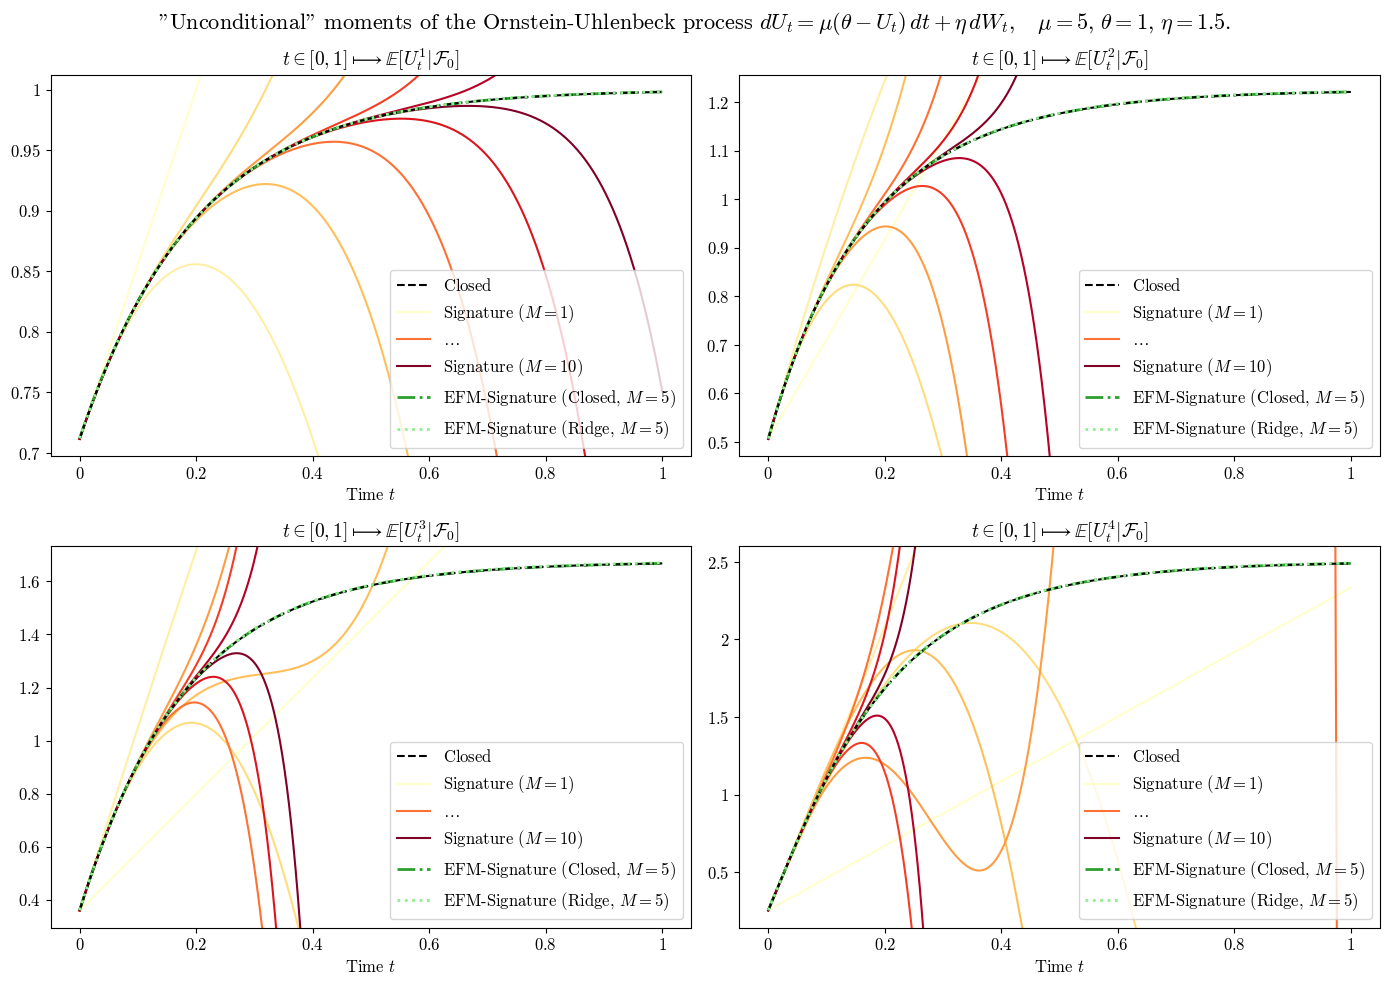

In [13]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm_ = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm_)
sm.set_array([])

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax = ax.flatten() 

ax[0].plot(t_main, mu_t, color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")
ax[1].plot(t_main, mu_t**2 + sigma_t_2, color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")
ax[2].plot(t_main, mu_t**3 + 3*mu_t*sigma_t_2, color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")
ax[3].plot(t_main, mu_t**4 + 6*mu_t**2*sigma_t_2 + 3*sigma_t_2**2, color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")

ylim0 = ax[0].get_ylim()
ylim1 = ax[1].get_ylim()
ylim2 = ax[2].get_ylim()
ylim3 = ax[3].get_ylim()

for i in range(4) : 
    for j, M in enumerate(M_values) : 
        color = cmap(norm_(M)) 
        if j == 0 or j == len(M_values)-1 : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0, label=r"$\text{Signature }$" + fr"$(M = {M})$")
        elif j == len(M_values)//2 : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0, label=r"$\ldots$")
        else : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0)
    ax[i].plot(t_main, moments_EFM_sig[i], lw=2, linestyle="-.", color="tab:green", zorder=0, label=r"$\text{EFM-Signature }(\text{Closed, }$" + fr"$M = {5})$")
    ax[i].plot(t_main, moments_EFM_sig_Ridge[i], lw=2, linestyle=":", color="lightgreen", label=r"$\text{EFM-Signature }(\text{Ridge, }$" + fr"$M = {5})$")
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(loc="lower right", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 
    ax[i].set_title(r"$t\in[0,1]\longmapsto\mathbb{E}[$" + fr"$U_t^{i+1}$" + r"$|\mathcal{F}_0]$", fontsize=14)

ax[0].set_ylim(ylim0)
ax[1].set_ylim(ylim1)
ax[2].set_ylim(ylim2)
ax[3].set_ylim(ylim3)

fig.suptitle(r"$\text{\"Unconditional\" moments of the Ornstein-Uhlenbeck process } dU_t = \mu(\theta-U_t)\, dt + \eta\, dW_t, \quad \mu = 5,\, \theta = 1,\, \eta=1.5.$", fontsize=16)
plt.tight_layout()
plt.show()

### II.2. Conditional moments 

#### II.2.1. Pleasant parameters

In [14]:
T = 1
T0 = -1
n1 = 500 # coarser grid for the burn-in 
n2 = T * 365 * 5 + 1
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0)

lambd = jnp.array([0.5, 0.5])
mu, theta, eta = 0.5, 0.0, 1.0

X_true = simulate_Langevin_Euler(0.0, mu, theta, eta, paths)
x = X_true[0, len(t_burn)]
x

np.float64(-0.5433702680551266)

In [15]:
idx_val = idx_train = n2 
#idx_train = int(0.75 * n2)
Y = X_true[0, len(t_burn):]

In [16]:
M = 5
shuffle_table = get_shuffle_table(M, d)
l = compute_l_OU(x, mu, theta, eta, M, d, shuffle_table)
sig = compute_signature(paths[:, len(t_burn):, :], M)
l_EFM = compute_l_EFM_OU(lambd, mu, theta, eta, M)
EFM_sig = compute_EFM_signature(paths, t_grid, lambd, M) 

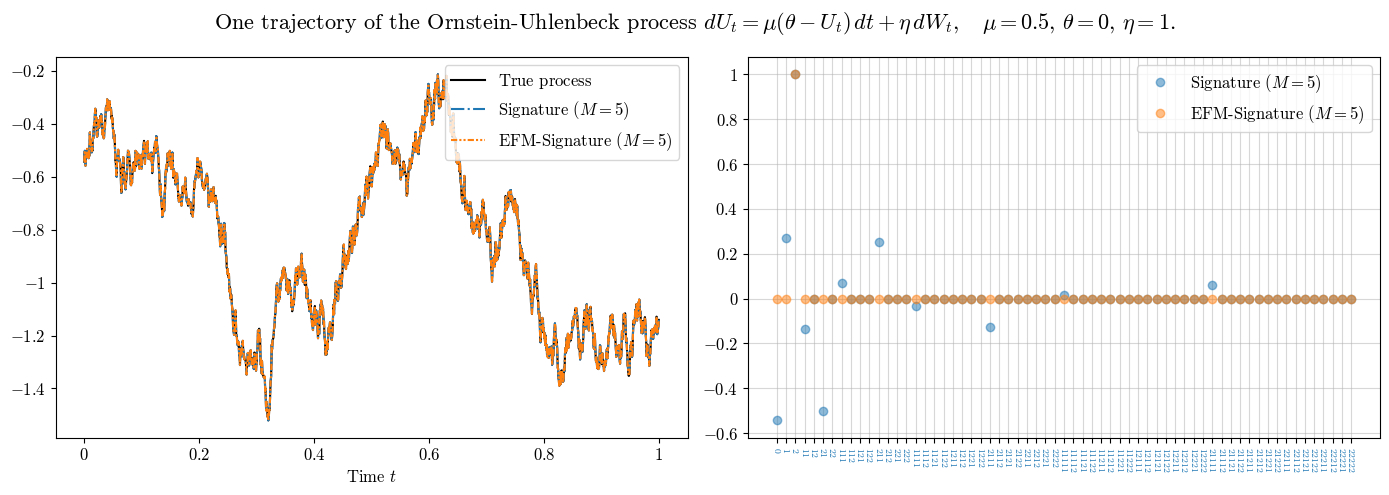

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(t_main, X_true[0, len(t_burn):], color="black", zorder=1, label=r"$\text{True process}$")
ax[0].plot(t_main, (sig @ l).T[0], linestyle="-.", color="tab:blue", label=r"$\text{Signature }$" + fr"$(M = {M})$")
ax[0].plot(t_main, (EFM_sig @ l_EFM).T[0], linestyle=(0, (3, 1, 1, 1, 1, 1)), color="tab:orange", label=r"$\text{EFM-Signature }$" + fr"$(M = {M})$")
ax[0].legend(fontsize=12)
ax[0].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[0].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[0].tick_params(axis='both', labelsize=12)
ax[0].set_xlabel(r"$\text{Time }t$", fontsize=12)

l.plot(ax=ax[1], color="tab:blue", label=r"$\text{Signature }$" + fr"$(M = {M})$", alpha=0.5, size_x=7)
l_EFM.plot(ax=ax[1], color="tab:orange", label=r"$\text{EFM-Signature }$" + fr"$(M = {M})$", alpha=0.5, size_x=7)

fig.suptitle(r"$\text{One trajectory of the Ornstein-Uhlenbeck process } dU_t = \mu(\theta-U_t)\, dt + \eta\, dW_t, \quad \mu = 0.5,\, \theta = 0,\, \eta=1.$", fontsize=16)

plt.tight_layout()
plt.show()

In [20]:
M_values = np.arange(1, 11) 
moments_sig = []
for M in tqdm(M_values) : 
    shuffle_table = get_shuffle_table(M, d)
    l = compute_l_OU(x, mu, theta, eta, M, d, shuffle_table)
    sig = compute_signature(paths[:, len(t_burn):, :], M)
    moments_sig.append(conditional_moments(k_grid, sig, t_main,  M, l))
moments_sig = np.array(moments_sig)

100%|███████████████████████████████████████████| 10/10 [01:00<00:00,  6.00s/it]


In [21]:
M = 5
l = compute_l_EFM_OU(lambd, mu, theta, eta, M)
EFM_sig = compute_EFM_signature(paths, t_grid, lambd, M) 
moments_EFM_sig = conditional_moments_EFM(k_grid, EFM_sig, t_main, lambd, M, l) 

In [22]:
mu_t = theta + (X_true[0, len(t_burn):] - theta) * np.exp(-mu * (t_main[-1] - t_main))
sigma_t_2 = 0.5 * eta**2 / mu *(1 - np.exp(-2 * mu * (t_main[-1] - t_main)))

In [24]:
M = 5
bounds = [(0.05, 5), (0.05, 5)]
init_guess = [0.5] * d 
lambda_opt = minimize_lambda(paths[0], Y, M, idx_train, idx_val, bounds, init_guess=init_guess, optimizer="Nelder-Mead", use_scaler=False)
lambda_opt 

lambda=[0.5 0.5] | RMSE=0.00000346
lambda=[0.525 0.5  ] | RMSE=0.00000374
lambda=[0.5   0.525] | RMSE=0.00000260
lambda=[0.475 0.525] | RMSE=0.00000259
lambda=[0.45   0.5375] | RMSE=0.00000219
lambda=[0.45   0.5625] | RMSE=0.00000165
lambda=[0.425   0.59375] | RMSE=0.00000135
lambda=[0.375   0.60625] | RMSE=0.00000147
lambda=[0.35   0.6625] | RMSE=0.00000132
lambda=[0.3   0.725] | RMSE=0.00000069
lambda=[0.35   0.7125] | RMSE=0.00000143
lambda=[0.35625   0.6859375] | RMSE=0.00000137
lambda=[0.36875   0.6328125] | RMSE=0.00000140
lambda=[0.359375   0.67265625] | RMSE=0.00000140
lambda=[0.3625   0.659375] | RMSE=0.00000137
lambda=[0.328125   0.70546875] | RMSE=0.00000122
lambda=[0.265625   0.77109375] | RMSE=0.00000041
lambda=[0.2171875  0.82695312] | RMSE=0.00000330
lambda=[0.2375   0.790625] | RMSE=0.00000189
lambda=[0.30546875 0.72675781] | RMSE=0.00000084
lambda=[0.26015625 0.76933594] | RMSE=0.00000067
lambda=[0.22578125 0.81542969] | RMSE=0.00000268
lambda=[0.28144531 0.74760742] |

array([0.27658731, 0.75472839])

In [25]:
#lambda_opt = np.array([4.84734949, 0.50020534]) 
EFM_sig_Ridge = compute_EFM_signature(paths, t_grid, lambda_opt, M)
start = time.time() 
model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge = regression_Ridge(Y, EFM_sig_Ridge[:, :, 0], M, idx_train, idx_val, verbose=False, use_scaler=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge) 

coef_EFM = get_full_coef(model_EFM_Ridge)
l_EFM_Ridge = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)

moments_EFM_sig_Ridge = conditional_moments_EFM(k_grid, EFM_sig_Ridge, t_main, lambd, M, l_EFM_Ridge) 

Ridge:  0.331942081451416  seconds, RMSE: 3.8312419903263617e-10


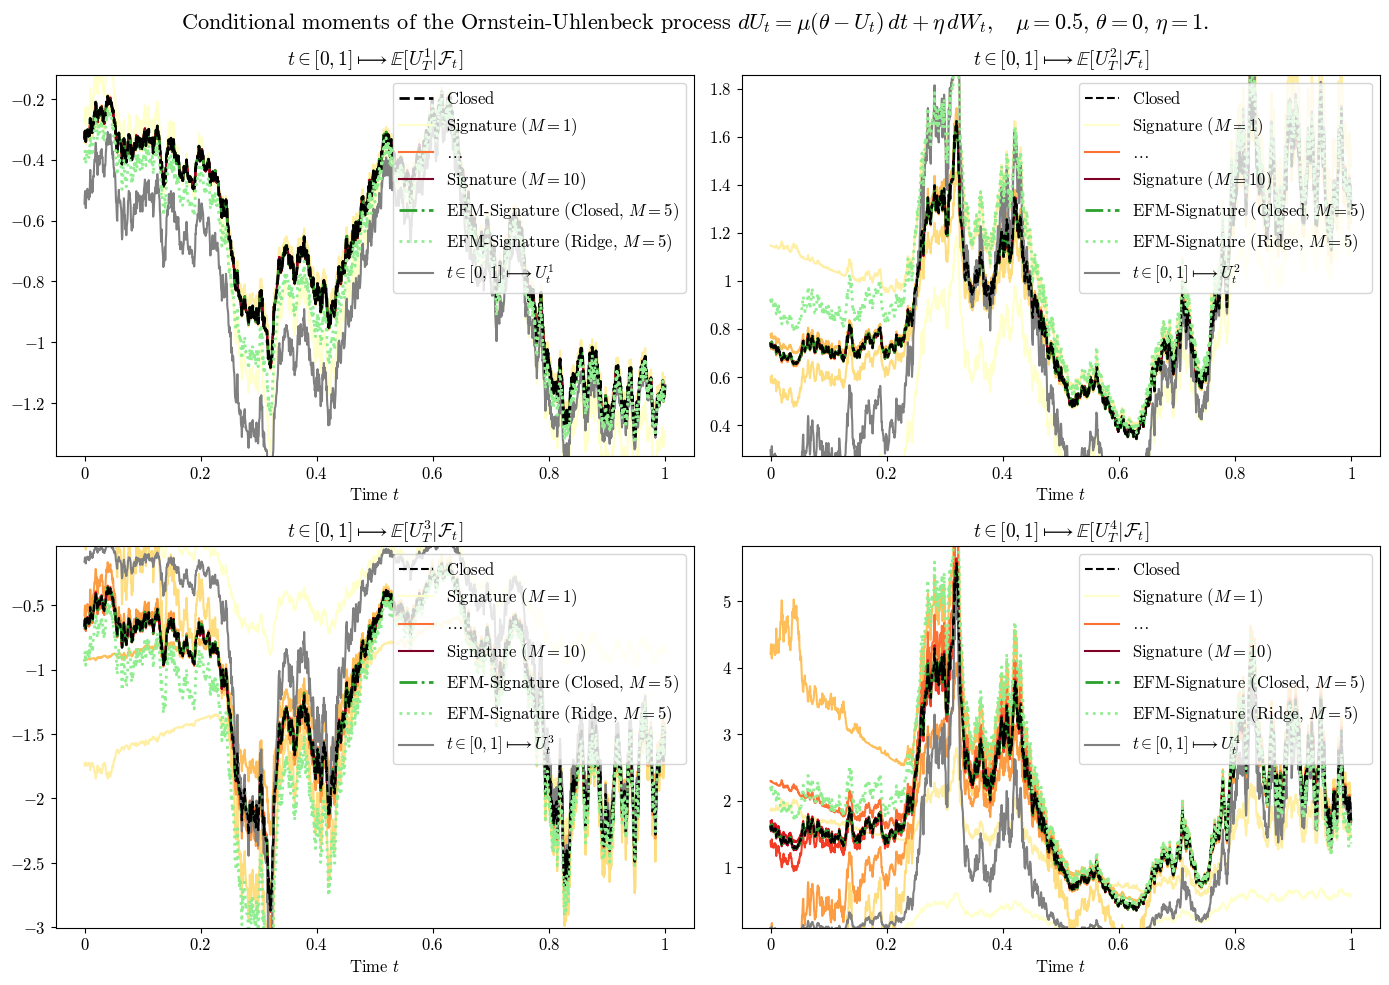

In [26]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm_ = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm_)
sm.set_array([])

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax = ax.flatten() 

ax[0].plot(t_main, mu_t, lw=2, color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")
ax[1].plot(t_main, mu_t**2 + sigma_t_2, color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")
ax[2].plot(t_main, mu_t**3 + 3*mu_t*sigma_t_2, color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")
ax[3].plot(t_main, mu_t**4 + 6*mu_t**2*sigma_t_2 + 3*sigma_t_2**2,  color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")

ylim0 = ax[0].get_ylim()
ylim1 = ax[1].get_ylim()
ylim2 = ax[2].get_ylim()
ylim3 = ax[3].get_ylim()

for i in range(4) : 
    for j, M in enumerate(M_values) : 
        color = cmap(norm_(M)) 
        if j == 0 or j == len(M_values)-1 : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0, label=r"$\text{Signature }$" + fr"$(M = {M})$")
        elif j == len(M_values)//2 : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0, label=r"$\ldots$")
        else : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0)
    ax[i].plot(t_main, moments_EFM_sig[i], lw=2, linestyle="-.", color="tab:green", zorder=0, label=r"$\text{EFM-Signature }(\text{Closed, }$" + fr"$M = {5})$")
    ax[i].plot(t_main, moments_EFM_sig_Ridge[i], lw=2, linestyle=":", color="lightgreen", label=r"$\text{EFM-Signature }(\text{Ridge, }$" + fr"$M = {5})$")
    ax[i].plot(t_main, X_true[0, len(t_burn):]**(i+1), color="gray", zorder=0, label=fr"$t\in[0,1]\longmapsto U_t^{i+1}$")
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(loc="upper right", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 
    ax[i].set_title(r"$t\in[0,1]\longmapsto\mathbb{E}[$" + fr"$U_T^{i+1}$" + r"$|\mathcal{F}_t]$", fontsize=14)

ax[0].set_ylim(ylim0)
ax[1].set_ylim(ylim1)
ax[2].set_ylim(ylim2)
ax[3].set_ylim(ylim3)

fig.suptitle(r"$\text{Conditional moments of the Ornstein-Uhlenbeck process } dU_t = \mu(\theta-U_t)\, dt + \eta\, dW_t, \quad \mu = 0.5,\, \theta = 0,\, \eta=1.$", fontsize=16)

plt.tight_layout()
plt.show()

#### II.2.2. A more realistic regime 

In [27]:
T = 1
T0 = -1
n1 = 500 # coarser grid for the burn-in 
n2 = T * 365 * 5 + 1
N = 1
k_grid, d = jnp.arange(1, 5), 2 
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0)

lambd = jnp.array([5, 5])
mu, theta, eta = 5, 1.0, 1.5

X_true = simulate_Langevin_Euler(0.0, mu, theta, eta, paths)
x = X_true[0, len(t_burn)]
x

np.float64(0.7113987145410022)

In [28]:
idx_train = idx_val = n2 
Y = X_true[0, len(t_burn):]

In [29]:
M = 5
shuffle_table = get_shuffle_table(M, d)
l = compute_l_OU(x, mu, theta, eta, M, d, shuffle_table)
sig = compute_signature(paths[:, len(t_burn):, :], M)
l_EFM = compute_l_EFM_OU(lambd, mu, theta, eta, M)
EFM_sig = compute_EFM_signature(paths, t_grid, lambd, M) 

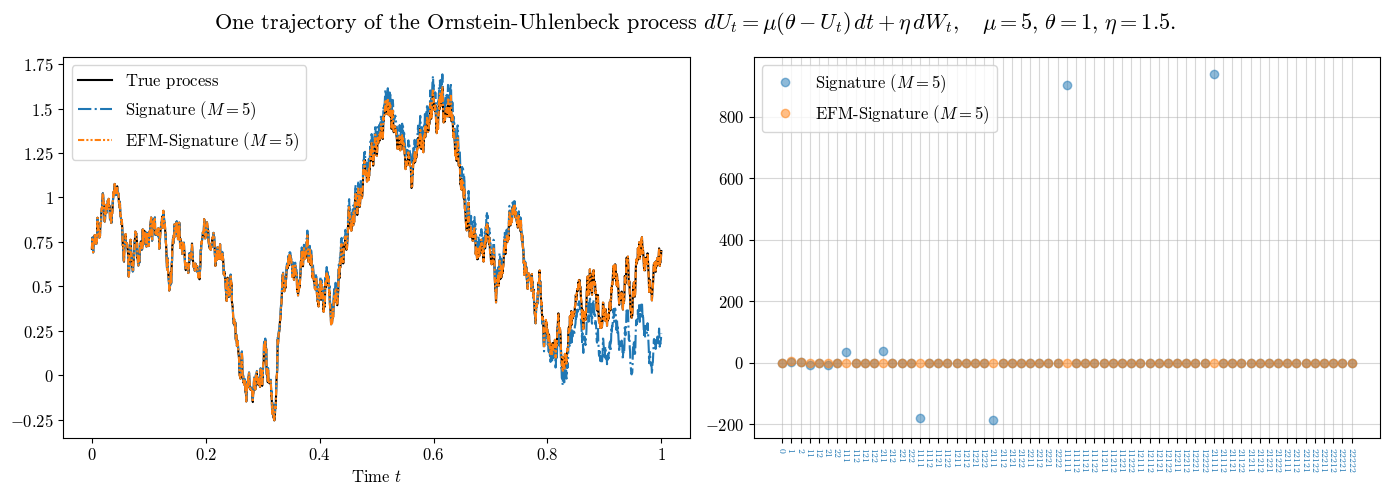

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(t_main, X_true[0, len(t_burn):], color="black", zorder=1, label=r"$\text{True process}$")
ax[0].plot(t_main, (sig @ l).T[0], linestyle="-.", color="tab:blue", label=r"$\text{Signature }$" + fr"$(M = {M})$")
ax[0].plot(t_main, (EFM_sig @ l_EFM).T[0], linestyle=(0, (3, 1, 1, 1, 1, 1)), color="tab:orange", label=r"$\text{EFM-Signature }$" + fr"$(M = {M})$")
ax[0].legend(fontsize=12)
ax[0].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax[0].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[0].tick_params(axis='both', labelsize=12)
ax[0].set_xlabel(r"$\text{Time }t$", fontsize=12)

l.plot(ax=ax[1], size_x=7, color="tab:blue", label=r"$\text{Signature }$" + fr"$(M = {M})$", alpha=0.5)
l_EFM.plot(ax=ax[1], size_x=7, color="tab:orange", label=r"$\text{EFM-Signature }$" + fr"$(M = {M})$", alpha=0.5)

fig.suptitle(r"$\text{One trajectory of the Ornstein-Uhlenbeck process } dU_t = \mu(\theta-U_t)\, dt + \eta\, dW_t, \quad \mu = 5,\, \theta = 1,\, \eta=1.5.$", fontsize=16)

plt.tight_layout()
plt.show()

In [31]:
M_values = np.arange(1, 11) 
moments_sig = []
for M in tqdm(M_values) : 
    shuffle_table = get_shuffle_table(M, d)
    l = compute_l_OU(x, mu, theta, eta, M, d, shuffle_table)
    sig = compute_signature(paths[:, len(t_burn):, :], M)
    moments_sig.append(conditional_moments(k_grid, sig, t_main,  M, l))
moments_sig = np.array(moments_sig)

100%|███████████████████████████████████████████| 10/10 [00:58<00:00,  5.81s/it]


In [32]:
M = 5
l = compute_l_EFM_OU(lambd, mu, theta, eta, M)
EFM_sig = compute_EFM_signature(paths, t_grid, lambd, M) 
moments_EFM_sig = conditional_moments_EFM(k_grid, EFM_sig, t_main, lambd, M, l) 

In [33]:
mu_t = theta + (X_true[0, len(t_burn):] - theta) * np.exp(-mu * (t_main[-1] - t_main))
sigma_t_2 = 0.5 * eta**2 / mu *(1 - np.exp(-2 * mu * (t_main[-1] - t_main)))

In [34]:
lambda_opt = np.array([4.60947685, 4.99977611])
EFM_sig_Ridge = compute_EFM_signature(paths, t_grid, lambda_opt, M)
start = time.time() 
model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge = regression_Ridge(Y, EFM_sig_Ridge[:, :, 0], M, idx_train, idx_val, verbose=False, use_scaler=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge) 

coef_EFM = get_full_coef(model_EFM_Ridge)
l_EFM_Ridge = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)

moments_EFM_sig_Ridge = conditional_moments_EFM(k_grid, EFM_sig_Ridge, t_main, lambd, M, l_EFM_Ridge) 

Ridge:  0.3266596794128418  seconds, RMSE: 2.628897100009908e-12


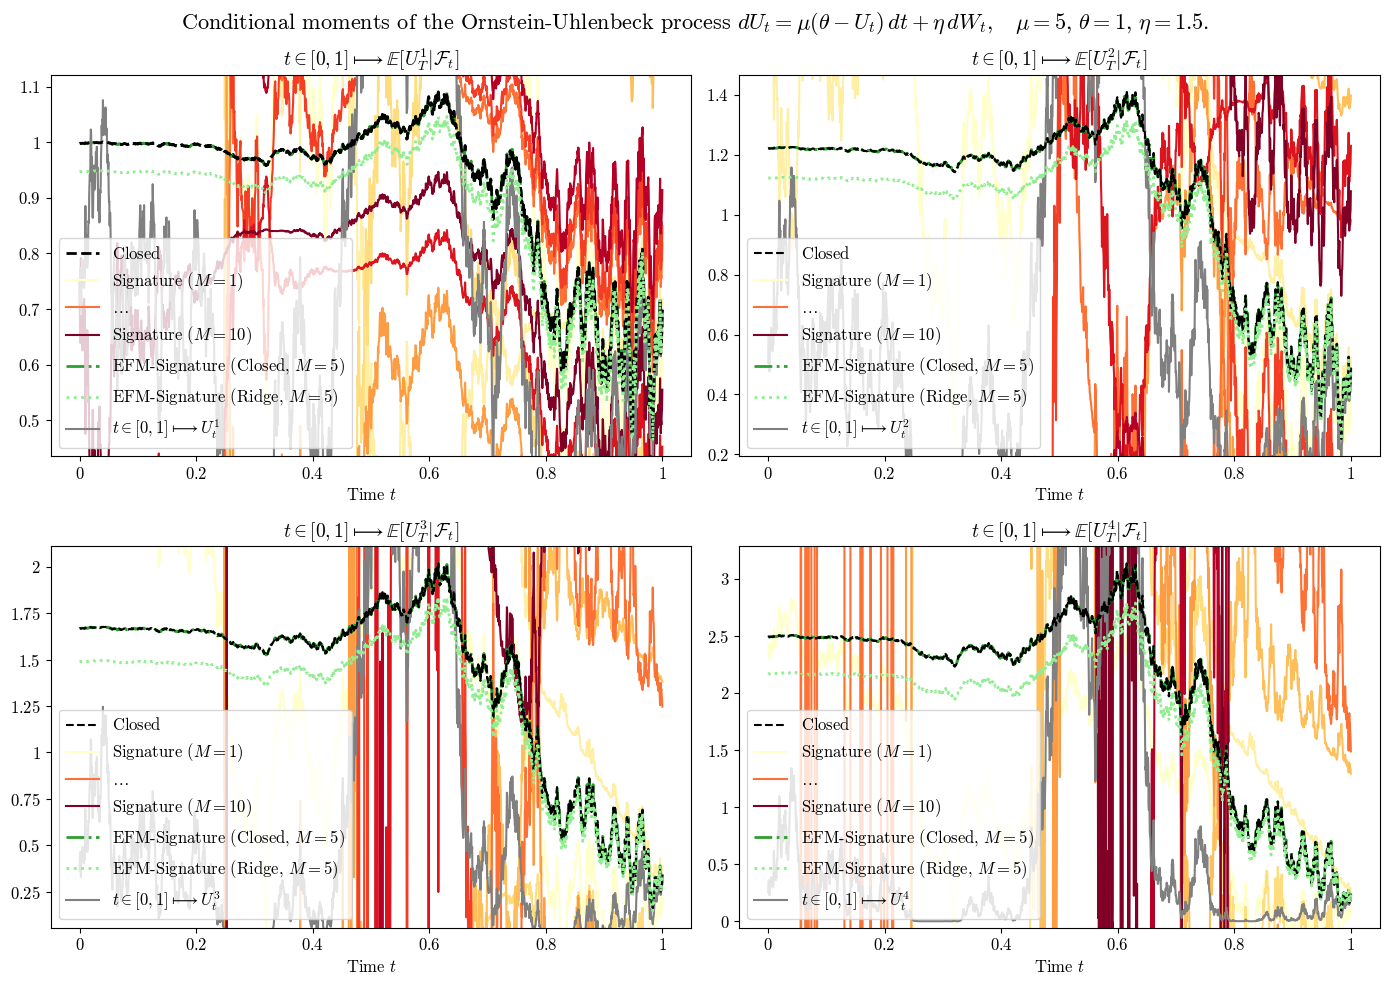

In [35]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm_ = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm_)
sm.set_array([])

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax = ax.flatten() 

ax[0].plot(t_main, mu_t, lw=2, color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")
ax[1].plot(t_main, mu_t**2 + sigma_t_2, color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")
ax[2].plot(t_main, mu_t**3 + 3*mu_t*sigma_t_2, color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")
ax[3].plot(t_main, mu_t**4 + 6*mu_t**2*sigma_t_2 + 3*sigma_t_2**2,  color="black", linestyle="--", zorder=1, label=r"$\text{Closed}$")

ylim0 = ax[0].get_ylim()
ylim1 = ax[1].get_ylim()
ylim2 = ax[2].get_ylim()
ylim3 = ax[3].get_ylim()

for i in range(4) : 
    for j, M in enumerate(M_values) : 
        color = cmap(norm_(M)) 
        if j == 0 or j == len(M_values)-1 : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0, label=r"$\text{Signature }$" + fr"$(M = {M})$")
        elif j == len(M_values)//2 : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0, label=r"$\ldots$")
        else : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0)    
    ax[i].plot(t_main, moments_EFM_sig[i], lw=2, linestyle="-.", color="tab:green", zorder=0, label=r"$\text{EFM-Signature }(\text{Closed, }$" + fr"$M = {5})$")
    ax[i].plot(t_main, moments_EFM_sig_Ridge[i], lw=2, linestyle=":", color="lightgreen", label=r"$\text{EFM-Signature }(\text{Ridge, }$" + fr"$M = {5})$")
    ax[i].plot(t_main, X_true[0, len(t_burn):]**(i+1), color="gray", zorder=0, label=fr"$t\in[0,1]\longmapsto U_t^{i+1}$")
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(loc="lower left", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 
    ax[i].set_title(r"$t\in[0,1]\longmapsto\mathbb{E}[$" + fr"$U_T^{i+1}$" + r"$|\mathcal{F}_t]$", fontsize=14)

ax[0].set_ylim(ylim0)
ax[1].set_ylim(ylim1)
ax[2].set_ylim(ylim2)
ax[3].set_ylim(ylim3)

fig.suptitle(r"$\text{Conditional moments of the Ornstein-Uhlenbeck process } dU_t = \mu(\theta-U_t)\, dt + \eta\, dW_t, \quad \mu = 5,\, \theta = 1,\, \eta=1.5.$", fontsize=16)

plt.tight_layout()
plt.show()

### II.3. Prediction 

In [181]:
T = 1
T0 = -1
n1 = 500 # coarser grid for the burn-in 
n2 = T * 365 * 5 + 1
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0)

lambd = jnp.array([5, 5])
mu, theta, eta = 5, 1.0, 1.5

X_true = simulate_Langevin_Euler(0.0, mu, theta, eta, paths)
x = X_true[0, len(t_burn)]
x

np.float64(0.7113987145410022)

In [182]:
M, d = 4, 2
shuffle_table = get_shuffle_table(M, d)
l = compute_l_EFM_OU(lambd, mu, theta, eta, M)
EFM_sig = compute_EFM_signature(paths, t_grid, lambd, M) 

In [191]:
idx = 1460
prediction, var = predict_conditional_expectation_EFM(EFM_sig, t_main, lambd, M, idx, l, shuffle_table)

100%|███████████████████████████████████████| 1827/1827 [18:13<00:00,  1.67it/s]


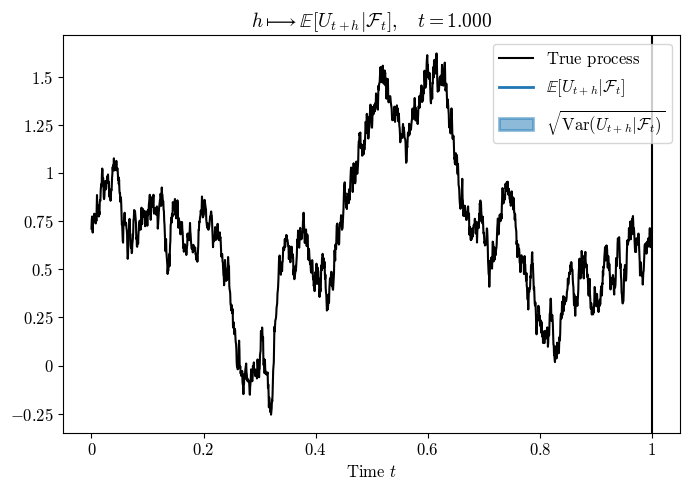

In [215]:
start_idx = 0
end_idx = 1827
predictions = []
variances = []
for idx in tqdm(range(start_idx, end_idx)):
    pred, var = predict_conditional_expectation_EFM(EFM_sig, t_main, lambd, M, idx, l, shuffle_table)
    predictions.append(pred)
    variances.append(np.maximum(var, 0))
    
fig, ax = plt.subplots(figsize=(7, 5))
y_true = X_true[0, len(t_burn):]
line_true, = ax.plot(t_main, y_true, label=r"$\text{True process}$", color="black")
lims = ax.get_ylim()
vline = ax.axvline(t_main[start_idx], linestyle="-", color="black")
line_pred, = ax.plot([], [], lw=2, label=r"$\mathbb{E}[U_{t+h}|\mathcal{F}_t]$", color="tab:blue")
fill_poly = ax.fill_between([], [], [], alpha=0.5, lw=2, color="tab:blue", label=r"$\sqrt{\text{Var}(U_{t+h}|\mathcal{F}_t)}$")
ax.legend(loc="upper right", fontsize=12)
ax.set_ylim(lims)
ax.xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax.yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax.tick_params(axis='both', labelsize=12) 
ax.set_xlabel(r"$\text{Time }t$", fontsize=12)
ax.set_title(r"$h\longmapsto\mathbb{E}[U_{t+h}|\mathcal{F}_t], \quad t = 0.000$", fontsize=14)
fig.tight_layout()

def init():
    vline.set_xdata([t_main[start_idx], t_main[start_idx]])
    line_pred.set_data([], [])
    return vline, line_pred

def update(k):
    global fill_poly
    idx = start_idx + k
    prediction = np.array(predictions[k])
    std = np.sqrt(np.array(variances[k]))
    t_pred = np.array(t_main[idx+1:])
    vline.set_xdata([t_main[idx], t_main[idx]])
    line_pred.set_data(t_pred, prediction)
    fill_poly.remove()
    fill_poly = ax.fill_between(t_pred, prediction - std, prediction + std, alpha=0.5, color="tab:blue")
    ax.set_title(r"$h\longmapsto \mathbb{E}[U_{t+h}|\mathcal{F}_t], \quad$" + fr"$t = {t_main[idx]:.3f}$", fontsize=14)
    return vline, line_pred

ani = FuncAnimation(fig, update, frames=range(end_idx - start_idx), init_func=init, blit=False, interval=50)

ani.save("animation.gif", writer=PillowWriter(fps=20), dpi=150)
plt.show()

## III. Moments of a CIR process (Regression + Markovian) 

In [2]:
v, theta, kappa, eta = 0.0625, 0.0625, 4, 0.2

In [3]:
T = 2
T0 = -1
n1 = 500 
n2 = int(T * 365 * 5 + 1)
N = 1
d = 2 
k_grid = jnp.arange(1, 5) 

### III.1. "Unconditional" moments 

In [4]:
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0, seed=11)

X_true = simulate_CIR_QE_on_R(v, kappa, theta, eta, paths)
x = X_true[0, len(t_burn)]
X_markov = simulate_CIR_QE(x, t_main[-1], kappa, theta, eta, paths[:, len(t_burn):, 1])
print(np.abs(X_markov - X_true[:, len(t_burn):]).max())
print(x)

idx_train = idx_val = n2 
idx_train, idx_val = int(1 * 365 * 5 + 1), int(1.5 * 365 * 5 + 1)
Y = X_true[0, len(t_burn):]

9.652764107193068e-07
0.06605904754317246


In [7]:
N_MC = 100000
paths_MC, _, _, _ = generate_two_sided_brownian_paths(N_MC, n1, n2, T, T0, seed=11)
X_MC = simulate_CIR_QE(x, t_main[-1], kappa, theta, eta, paths_MC[:, len(t_burn):, 1])

In [8]:
E_X_1, _, E_X_1_lower, E_X_1_upper = monte_carlo(X_MC**1, mode="axis0")
E_X_2, _, E_X_2_lower, E_X_2_upper = monte_carlo(X_MC**2, mode="axis0")
E_X_3, _, E_X_3_lower, E_X_3_upper = monte_carlo(X_MC**3, mode="axis0")
E_X_4, _, E_X_4_lower, E_X_4_upper = monte_carlo(X_MC**4, mode="axis0")

In [9]:
M_values = np.arange(1, 11) 
moments_sig = []
for M in tqdm(M_values) : 
    l = compute_l_CIR(np.sqrt(x), kappa, theta, eta, M)
    l_Tensor = Tensor(array=jnp.concat([jnp.asarray([x]), jnp.asarray(l)]), M=M, d=d)
    moments_sig.append(unconditional_moments(k_grid, t_main,  M, l_Tensor))
moments_sig = np.array(moments_sig)

100%|███████████████████████████████████████████| 10/10 [01:54<00:00, 11.41s/it]


In [10]:
M = 6

bounds = [(0.1, 20), (0.1, 20)]
init_guess = [5] * d 
lambda_opt = minimize_lambda(paths[0], Y, M, idx_train, idx_val, bounds, init_guess=init_guess, optimizer="Powell", use_scaler=False)

lambda=[5. 5.] | RMSE=0.00128251
lambda=[7.70112362 5.        ] | RMSE=0.00168068
lambda=[12.39887638  5.        ] | RMSE=0.00240015
lambda=[4.79775275 5.        ] | RMSE=0.00127519
lambda=[3.00337087 5.        ] | RMSE=0.00105564
lambda=[1.89438188 5.        ] | RMSE=0.00115636
lambda=[3.06737195 5.        ] | RMSE=0.00105946
lambda=[2.80248681 5.        ] | RMSE=0.00104743
lambda=[2.45562159 5.        ] | RMSE=0.00105285
lambda=[2.70483836 5.        ] | RMSE=0.00104596
lambda=[2.69247407 5.        ] | RMSE=0.00104591
lambda=[2.68075689 5.        ] | RMSE=0.00104590
lambda=[2.68212502 5.        ] | RMSE=0.00104590
lambda=[2.68245839 5.        ] | RMSE=0.00104590
lambda=[2.68179165 5.        ] | RMSE=0.00104590
lambda=[2.68212502 7.70112362] | RMSE=0.00517248
lambda=[ 2.68212502 12.39887638] | RMSE=0.00716099
lambda=[2.68212502 4.79775275] | RMSE=0.00095443
lambda=[2.68212502 3.00337087] | RMSE=0.00046859
lambda=[2.68212502 3.36253327] | RMSE=0.00053872
lambda=[2.68212502 1.89438188] |

In [6]:
lambda_opt = np.array([1.544e+00,  1.816e+00]) 
EFM_sig = compute_EFM_signature(paths, t_grid, lambda_opt, M) 
start = time.time() 
model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge = regression_Ridge(Y, EFM_sig[:, :, 0], M, idx_train, idx_val, verbose=False, use_scaler=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge) 

coef_EFM = get_full_coef(model_EFM_Ridge)
l_EFM_Ridge = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)
moments_EFM_sig = unconditional_moments_EFM(k_grid, EFM_sig, t_main, lambda_opt, M, l_EFM_Ridge) 

Ridge:  1.0832929611206055  seconds, RMSE: 5.387098193192691e-05


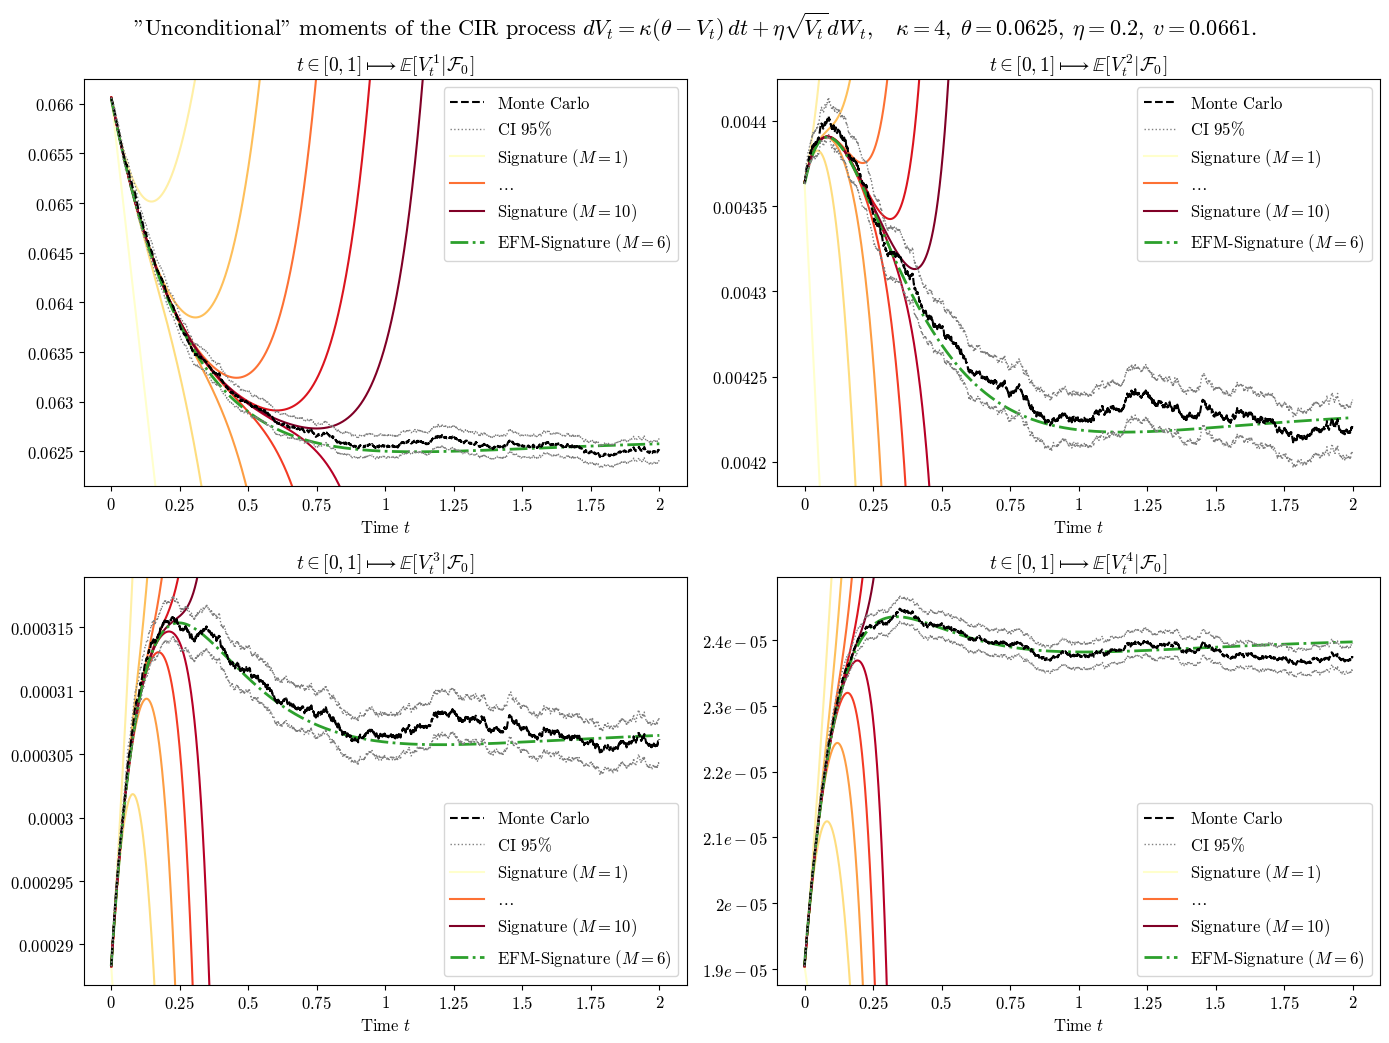

In [10]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm_ = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm_)
sm.set_array([])

fig, ax = plt.subplots(2, 2, figsize=(14, 10.6))
ax = ax.flatten() 

ax[0].plot(t_main, E_X_1, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[0].plot(t_main, E_X_1_lower, color="gray", linestyle=":", lw=1, label=r"$\text{CI }95\%$")
ax[0].plot(t_main, E_X_1_upper, color="gray", linestyle=":", lw=1)
ax[1].plot(t_main, E_X_2, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[1].plot(t_main, E_X_2_lower, color="gray", linestyle=":", lw=1, label=r"$\text{CI }95\%$")
ax[1].plot(t_main, E_X_2_upper, color="gray", linestyle=":", lw=1)

ax[2].plot(t_main, E_X_3, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[2].plot(t_main, E_X_3_lower, color="gray", linestyle=":", lw=1, label=r"$\text{CI }95\%$")
ax[2].plot(t_main, E_X_3_upper, color="gray", linestyle=":", lw=1)

ax[3].plot(t_main, E_X_4, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[3].plot(t_main, E_X_4_lower, color="gray", linestyle=":", lw=1, label=r"$\text{CI }95\%$")
ax[3].plot(t_main, E_X_4_upper, color="gray", linestyle=":", lw=1)

ylim0 = ax[0].get_ylim()
ylim1 = ax[1].get_ylim()
ylim2 = ax[2].get_ylim()
ylim3 = ax[3].get_ylim()

for i in range(4) : 
    for j, M in enumerate(M_values) : 
        color = cmap(norm_(M)) 
        if j == 0 or j == len(M_values)-1 : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0, label=r"$\text{Signature }$" + fr"$(M = {M})$")
        elif j == len(M_values)//2 : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0, label=r"$\ldots$")
        else : 
            ax[i].plot(t_main, moments_sig[j, i], color=color, zorder=0)
    ax[i].plot(t_main, moments_EFM_sig[i], lw=2, linestyle="-.", color="tab:green", zorder=0, label=r"$\text{EFM-Signature }$" + fr"$(M = {6})$")
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(loc="best", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 
    ax[i].set_title(r"$t\in[0,1]\longmapsto\mathbb{E}[$" + fr"$V_t^{{\, {i+1}}}$" + r"$|\mathcal{F}_0]$", fontsize=14)

ax[0].set_ylim(ylim0)
ax[1].set_ylim(ylim1)
ax[2].set_ylim(ylim2)
ax[3].set_ylim(ylim3)

fig.suptitle(r"$\text{\"Unconditional\" moments of the CIR process }dV_t = \kappa(\theta-V_t)\, dt + \eta\sqrt{\!V_t} dW_t,\quad$"
             fr"$\kappa = {kappa},\; \theta = {theta},\; \eta = {eta}, \; v={np.round(x, 4)}.$", fontsize=16)
plt.tight_layout()
plt.show()

### III.2. Conditional moments

In [11]:
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0, seed=11)

X_true = simulate_CIR_QE_on_R(v, kappa, theta, eta, paths)
x = X_true[0, len(t_burn)]
X_markov = simulate_CIR_QE(x, t_main[-1], kappa, theta, eta, paths[:, len(t_burn):, 1])
print(np.abs(X_markov - X_true[:, len(t_burn):]).max())
print(x)

idx_train = idx_val = n2 
idx_train, idx_val = int(1 * 365 * 5 + 1), int(1.5 * 365 * 5 + 1)
Y = X_true[0, len(t_burn):]

9.652764107193068e-07
0.06605904754317246


In [12]:
M_values = np.arange(1, 11) 
moments_sig = []
for M in tqdm(M_values) : 
    shuffle_table = get_shuffle_table(M, d)
    l = compute_l_CIR(np.sqrt(x), kappa, theta, eta, M)
    l_Tensor = Tensor(array=jnp.concat([jnp.asarray([x]), jnp.asarray(l)]), M=M, d=d)
    sig = compute_signature(paths[:, len(t_burn):, :], M)
    moments_sig.append(conditional_moments(k_grid, sig, t_main,  M, l_Tensor))
moments_sig = np.array(moments_sig)

100%|███████████████████████████████████████████| 10/10 [01:57<00:00, 11.75s/it]


In [13]:
M = 6
lambda_opt = np.array([1.544e+00,  1.816e+00])

EFM_sig = compute_EFM_signature(paths, t_grid, lambda_opt, M) 
start = time.time() 
model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge = regression_Ridge(Y, EFM_sig[:, :, 0], M, idx_train, idx_val, verbose=False, use_scaler=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge) 

coef_EFM = get_full_coef(model_EFM_Ridge)
l_EFM_Ridge = Tensor(array=jnp.asarray(coef_EFM), M=M, d=2)

moments_EFM_sig = conditional_moments_EFM(k_grid, EFM_sig, t_main, lambda_opt, M, l_EFM_Ridge) 

Ridge:  0.5870499610900879  seconds, RMSE: 5.387098193192691e-05


In [115]:
N_MC = 1000
T_final = t_main[-1]
moments_nested, moments_nested_lower, moments_nested_upper = np.zeros((n2+1, len(k_grid))), np.zeros((n2+1, len(k_grid))), np.zeros((n2+1, len(k_grid))) 

for i in tqdm(range(n2+1)):
    t_ = t_main[i]
    h = T_final - t_
    
    if h < 1e-6:  
        for ki, k in enumerate(k_grid):
            moments_nested[i, ki] = X_true[0, len(t_burn) + i]**k
        continue
    
    v_t = X_true[0, len(t_burn) + i]  # V_t observé
    
    n_inner = max(int(h * 365 * 5), 2)
    dW = np.random.randn(N_MC, n_inner - 1) * np.sqrt(h / (n_inner - 1))
    W_inner = np.concatenate([np.zeros((N_MC, 1)), np.cumsum(dW, axis=1)], axis=1)
    
    X_inner = simulate_CIR_QE(v_t, h, kappa, theta, eta, W_inner)
    
    for ki, k in enumerate(k_grid):
        mean, _, lower, upper = monte_carlo(X_inner[:, -1]**k)
        moments_nested[i, ki] = mean 
        moments_nested_lower[i, ki] = lower
        moments_nested_upper[i, ki] = upper

100%|███████████████████████████████████████| 3652/3652 [10:14<00:00,  5.94it/s]


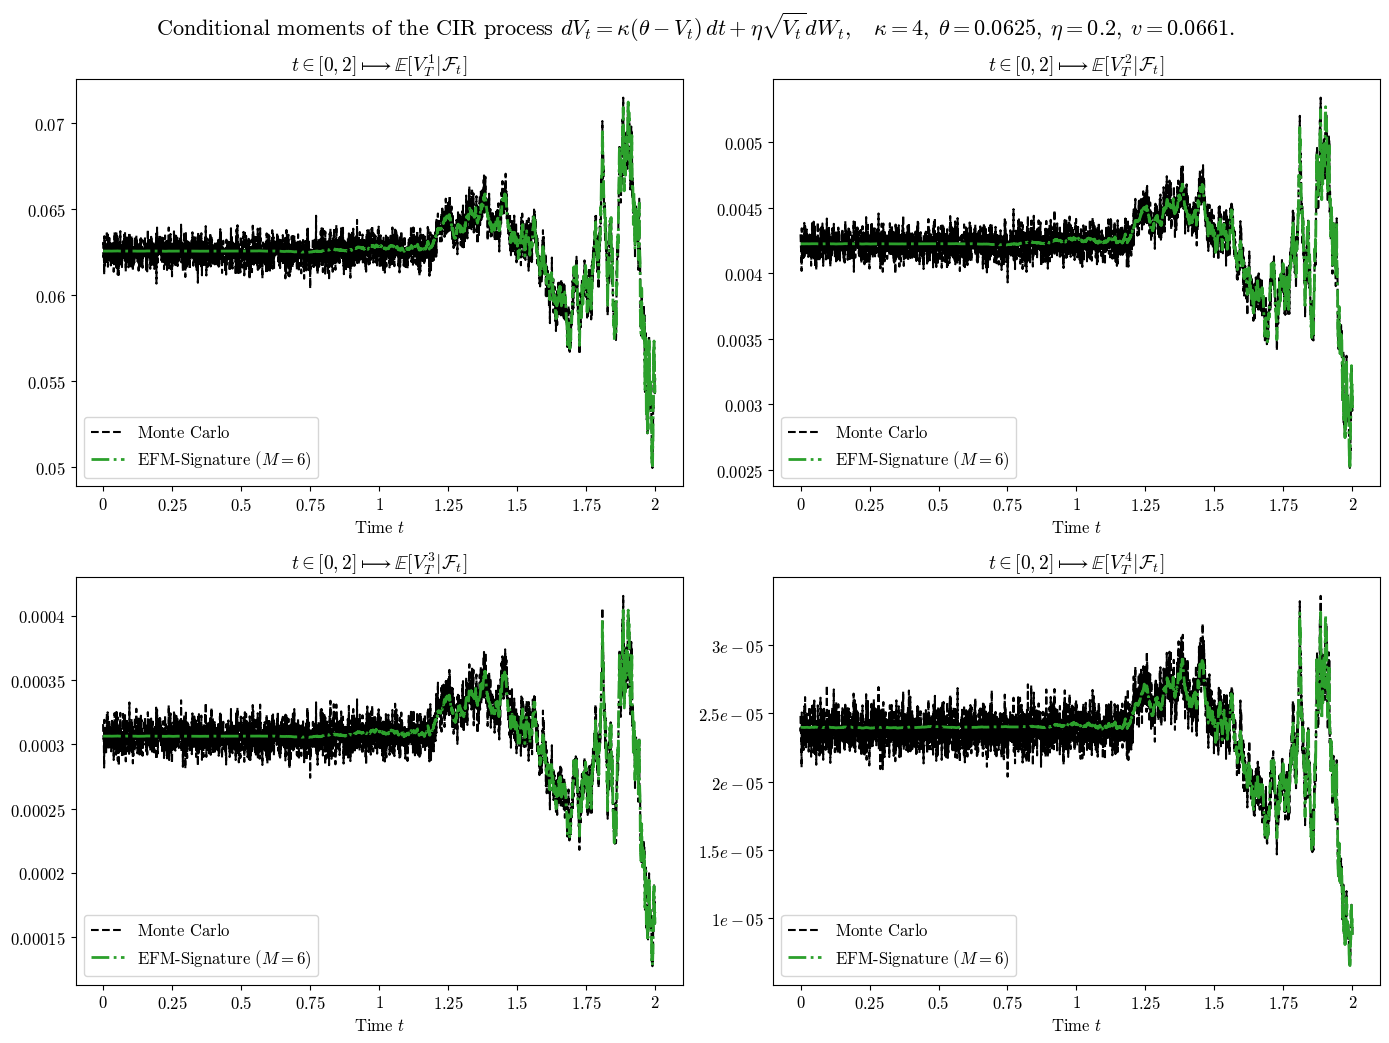

In [133]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm_ = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm_)
sm.set_array([])

fig, ax = plt.subplots(2, 2, figsize=(14, 10.6))
ax = ax.flatten() 

for i in range(4) : 
    ax[i].plot(t_main, moments_nested[:, i], color="black", linestyle="--", label=r"$\text{Monte Carlo}$", zorder=0)

ylim0 = ax[0].get_ylim()
ylim1 = ax[1].get_ylim()
ylim2 = ax[2].get_ylim()
ylim3 = ax[3].get_ylim()

for i in range(4) : 
    ax[i].plot(t_main, moments_EFM_sig[i], lw=2, linestyle="-.", color="tab:green", zorder=0, label=r"$\text{EFM-Signature }$" + fr"$(M = {6})$")
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(loc="lower left", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 
    ax[i].set_title(r"$t\in[0,2]\longmapsto\mathbb{E}[$" + fr"$V_T^{{\, {i+1}}}$" + r"$|\mathcal{F}_t]$", fontsize=14)

ax[0].set_ylim(ylim0)
ax[1].set_ylim(ylim1)
ax[2].set_ylim(ylim2)
ax[3].set_ylim(ylim3)

fig.suptitle(r"$\text{Conditional moments of the CIR process }dV_t = \kappa(\theta-V_t)\, dt + \eta\sqrt{\!V_t} dW_t,\quad$"
             fr"$\kappa = {kappa},\; \theta = {theta},\; \eta = {eta}, \; v={np.round(x, 4)}.$", fontsize=16)
plt.tight_layout()
plt.show()

## IV. Gaussian Volterra process 

### IV.1. Gamma kernel 

In [2]:
H = 0.1
nu = 50 
T = 0.1
T0 = -0.1
tau = 0
n_fact = 8   

In [3]:
n1 = n2 = 1000
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0)

In [4]:
theta, eta = 0, 1

r_star, w_star, x_star = compute_r_optimal(n_fact, H, tau, T-T0, eps=0.0, nu=nu, r_min=1.0001, r_max=5.0)

In [5]:
OUs = np.array([simulate_Langevin_Euler(0.0, x_star[i], theta, eta, paths)[0] for i in tqdm(range(len(x_star)))]) 
traj_Gamma = np.sum(w_star[:, None] * OUs, axis=0)

100%|█████████████████████████████████████████████| 8/8 [00:01<00:00,  5.10it/s]


In [6]:
M = 3
time_coord = paths[:, :, [0]]          
last_coord = np.repeat(paths[:, :, [-1]], n_fact, axis=2)   

extended_paths = np.concatenate([time_coord, last_coord], axis=2)
extended_paths.shape

lambd = np.concatenate([[0], x_star])
EFM_sig = compute_EFM_signature(extended_paths, t_grid, lambd, M) 
extended_d = extended_paths.shape[-1]
l_X_array = jnp.zeros(number_of_words(M=M, d=extended_d))

In [7]:
k_grid = jnp.arange(1,4)
l_X_array = jnp.zeros(number_of_words(M=M, d=extended_d))
for i in range(n_fact) : 
    l_X_array = l_X_array.at[i+2].set(w_star[i])

l_X = Tensor(array=l_X_array, d=extended_d, M=M)
moments = unconditional_moments_EFM_same_bm(k_grid, EFM_sig, t_main, lambd, M=M, l=l_X, d=extended_d) 
conditional_moments = conditional_moments_EFM_same_bm(k_grid, EFM_sig, t_main, lambd, M, l=l_X, d=extended_d)

In [8]:
traj_OUs = []
l_OUs = []
for i, x in enumerate(tqdm(x_star)) : 
    l = compute_l_EFM_OU(x, x, theta, eta, M)
    EFM_sig = compute_EFM_signature(paths, t_grid, x, M) 
    traj_OUs.append((EFM_sig @ l).T[0])
    l_OUs.append(l) 
traj_OUs = np.array(traj_OUs)

100%|█████████████████████████████████████████████| 8/8 [00:01<00:00,  5.56it/s]


In [9]:
dW_past = np.diff(paths[0, :len(t_burn), 1]) 
t_past = t_burn[:-1]  

E_X_t_given_F0 = np.zeros(len(t_main))
for i, t_ in enumerate(t_main):
    E_X_t_given_F0[i] = np.sum(K_gamma(t_ - t_past, H, nu) * dW_past)

In [10]:
xx = x_star[:, None] + x_star[None, :]          
ww = w_star[:, None] * w_star[None, :]          

V_t_multifactor = np.sum((ww / xx)[:, :, None] * (1 - np.exp(-xx[:, :, None] * t_main[None, None, :])), axis=(0, 1))  

A_t_multifactor = np.sum(w_star[:, None] * np.exp(-x_star[:, None] * t_main[None, :]) * OUs[:, len(t_burn), None], axis=0)  

E_X_1_multifactor = A_t_multifactor
E_X_2_multifactor = A_t_multifactor**2 + V_t_multifactor
E_X_3_multifactor = A_t_multifactor**3 + 3 * A_t_multifactor * V_t_multifactor
E_X_4_multifactor = A_t_multifactor**4 + 6 * A_t_multifactor**2 * V_t_multifactor + 3 * V_t_multifactor**2

In [11]:
A_T_t_multifactor = np.sum(w_star[:, None] * np.exp(-x_star[:, None] * (T - t_main[None,:])) * OUs[:, len(t_burn):], axis=0)
h = T - t_main  
V_T_t_multifactor = np.sum((ww/xx)[:,:,None] * (1 - np.exp(-xx[:,:,None] * h[None,None,:])), axis=(0,1))

E_X_1_t_multifactor = A_T_t_multifactor
E_X_2_t_multifactor = A_T_t_multifactor**2 + V_T_t_multifactor
E_X_3_t_multifactor = A_T_t_multifactor**3 + 3 * A_T_t_multifactor * V_T_t_multifactor
E_X_4_t_multifactor = A_T_t_multifactor**4 + 6 * A_T_t_multifactor**2 * V_T_t_multifactor + 3 * V_T_t_multifactor**2

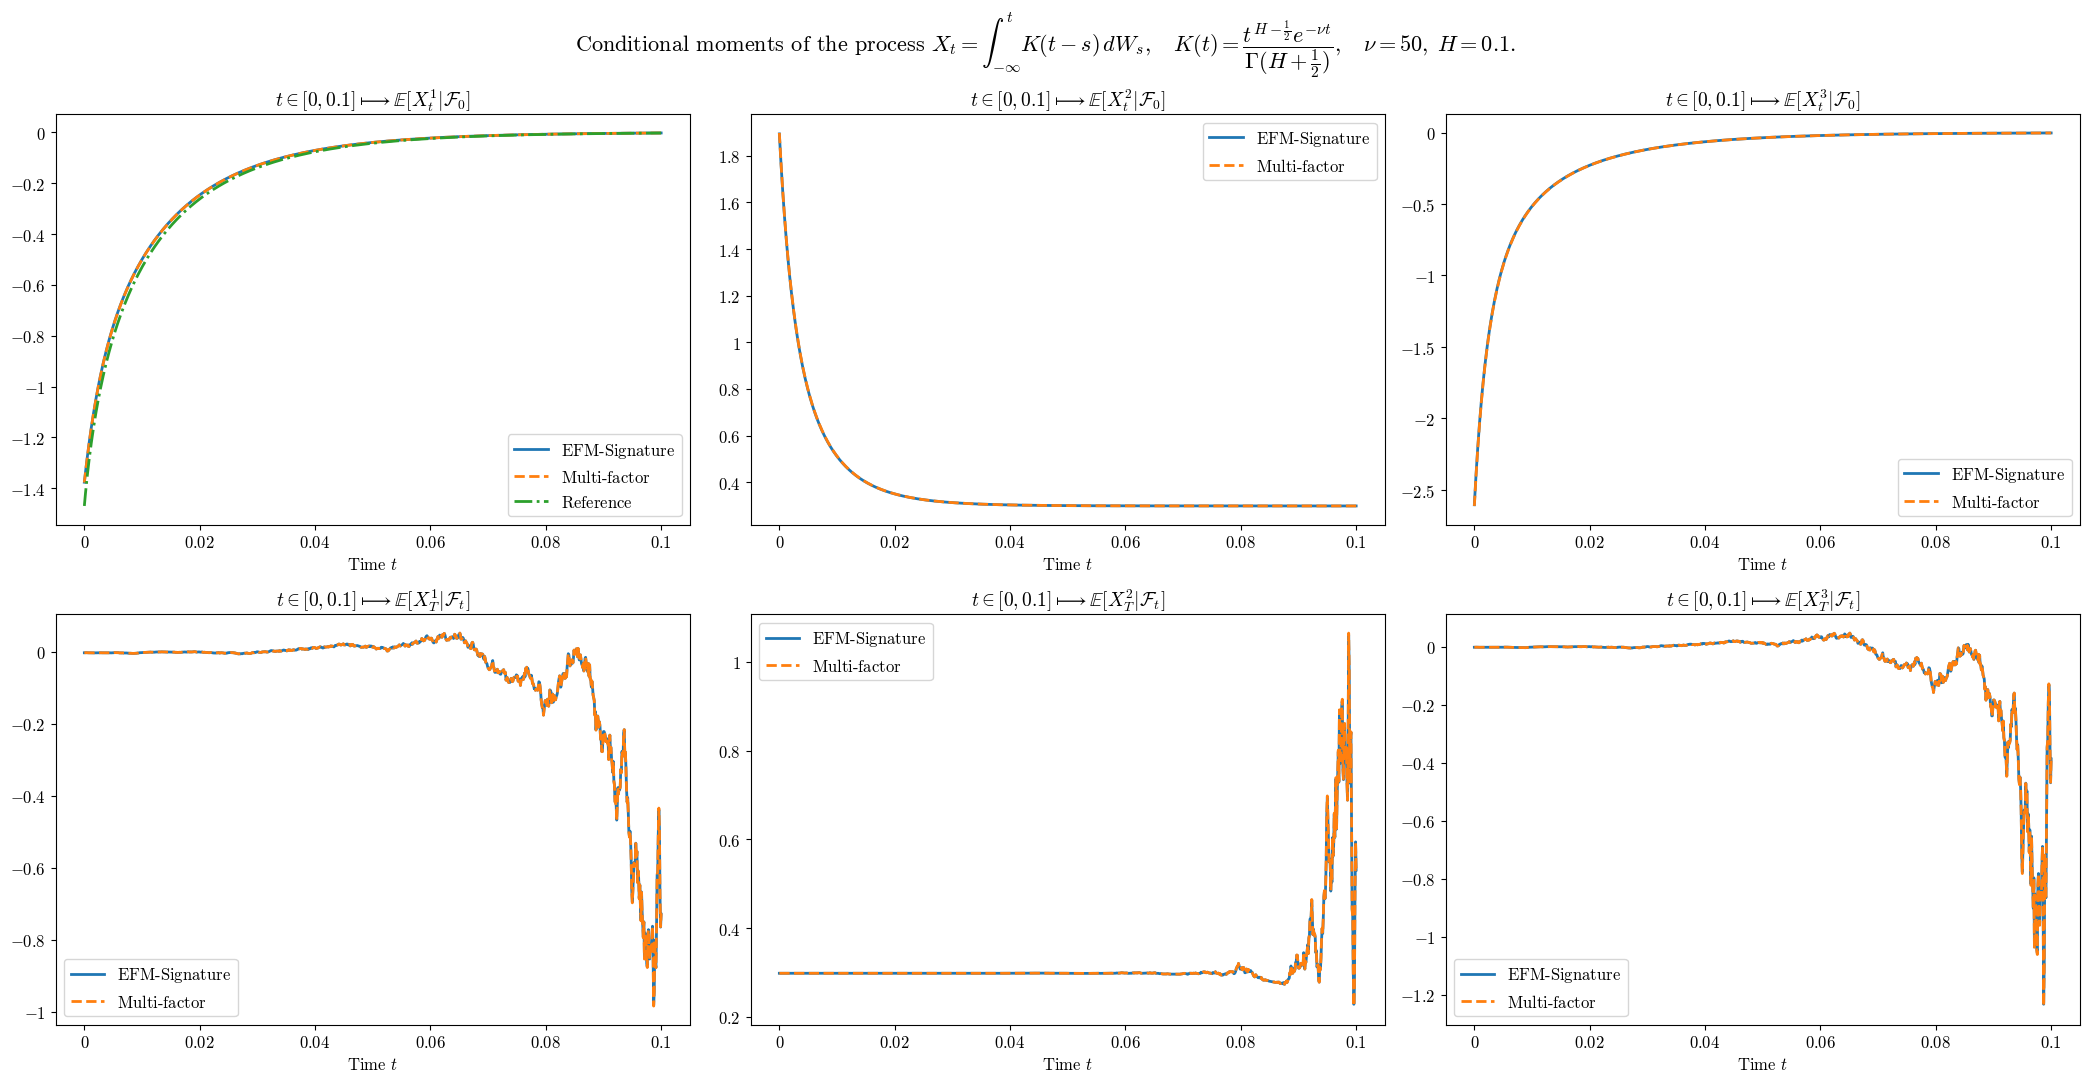

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(21, 11))
ax = ax.flatten()
for i in range(3) : 
    ax[i].plot(t_main, moments[i], lw=2, color="tab:blue", label=r"$\text{EFM-Signature}$")
    ax[i+3].plot(t_main, conditional_moments[i], lw=2, color="tab:blue", label=r"$\text{EFM-Signature}$")
    ax[i].set_title(r"$t\in [0, 0.1]\longmapsto \mathbb{E}[$" + fr"$X_t^{i+1}$" + r"$|\mathcal{F}_0]$", fontsize=14)
    ax[i+3].set_title(r"$t\in [0, 0.1]\longmapsto \mathbb{E}[$" + fr"$X_T^{i+1}$" + r"$|\mathcal{F}_t]$", fontsize=14)

ax[0].plot(t_main, E_X_1_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")
ax[0].plot(t_main, E_X_t_given_F0, linestyle="-.", lw=2, color="tab:green", label=r"$\text{Reference}$")
ax[1].plot(t_main, E_X_2_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")
ax[2].plot(t_main, E_X_3_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")

ax[3].plot(t_main, E_X_1_t_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")
ax[4].plot(t_main, E_X_2_t_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")
ax[5].plot(t_main, E_X_3_t_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")

for i in range(6) : 
    ax[i].tick_params(axis='both', labelsize=12) 
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(fontsize=12)

fig.suptitle(r"$\text{Conditional moments of the process }X_t = \int_{-\infty}^t K(t-s)\, dW_s,\quad K(t) = \dfrac{t^{H-\frac{1}{2}}e^{-\nu t}}{\Gamma(H+\frac{1}{2})},\quad$"
             fr"$\nu = {nu},\; H = {H}.$", fontsize=16)
    
plt.tight_layout()
plt.show()

### VI.2. Shifted fractional kernel 

In [13]:
H = 0.1
eps = 1/52
T = 1/12      
T0 = -1/12     
tau = 0
n_fact = 8  

In [14]:
n1 = n2 = 252
N = 1
paths, t_burn, t_main, t_grid = generate_two_sided_brownian_paths(N, n1, n2, T, T0)

In [15]:
theta, eta = 0, 1 

r_star, w_star, x_star = compute_r_optimal(n_fact, H, tau, T-T0, eps=eps, nu=0.0, r_min=1.0001, r_max=5.0)

In [16]:
OUs = np.array([simulate_Langevin_Euler(0.0, x_star[i], theta, eta, paths)[0] for i in tqdm(range(len(x_star)))]) 
traj_Gamma = np.sum(w_star[:, None] * OUs, axis=0)

100%|█████████████████████████████████████████████| 8/8 [00:00<00:00, 17.73it/s]


In [17]:
M = 3
time_coord = paths[:, :, [0]]          
last_coord = np.repeat(paths[:, :, [-1]], n_fact, axis=2)   

extended_paths = np.concatenate([time_coord, last_coord], axis=2)
extended_paths.shape

lambd = np.concatenate([[0], x_star])
EFM_sig = compute_EFM_signature(extended_paths, t_grid, lambd, M) 
extended_d = extended_paths.shape[-1]
l_X_array = jnp.zeros(number_of_words(M=M, d=extended_d))

In [18]:
k_grid = jnp.arange(1,4)
l_X_array = jnp.zeros(number_of_words(M=M, d=extended_d))
for i in range(n_fact) : 
    l_X_array = l_X_array.at[i+2].set(w_star[i])

l_X = Tensor(array=l_X_array, d=extended_d, M=M)
moments = unconditional_moments_EFM_same_bm(k_grid, EFM_sig, t_main, lambd, M=M, l=l_X, d=extended_d) 
conditional_moments = conditional_moments_EFM_same_bm(k_grid, EFM_sig, t_main, lambd, M, l=l_X, d=extended_d)

In [19]:
traj_OUs = []
l_OUs = []
for i, x in enumerate(tqdm(x_star)) : 
    l = compute_l_EFM_OU(x, x, theta, eta, M)
    EFM_sig = compute_EFM_signature(paths, t_grid, x, M) 
    traj_OUs.append((EFM_sig @ l).T[0])
    l_OUs.append(l) 
traj_OUs = np.array(traj_OUs)

100%|█████████████████████████████████████████████| 8/8 [00:00<00:00,  9.21it/s]


In [20]:
dW_past = np.diff(paths[0, :len(t_burn), 1]) 
t_past = t_burn[:-1] 

E_X_t_given_F0 = np.zeros(len(t_main))
for i, t_ in enumerate(t_main):
    E_X_t_given_F0[i] = np.sum(K_shift(t_ - t_past, H, eps) * dW_past)

In [21]:
V_t = np.zeros(len(t_main))
for i, t_ in enumerate(t_main):
    if t_ < 1e-10:
        V_t[i] = 0.0
    else:
        s_grid = np.linspace(0, t_, 1000)
        K_vals = K_shift(s_grid, H, eps)  
        V_t[i] = np.trapezoid(K_vals**2, s_grid)

A_t = E_X_t_given_F0  

E_X_2_exact = A_t**2 + V_t           
E_X_3_exact = A_t**3 + 3*A_t*V_t    
E_X_4_exact = A_t**4 + 6*A_t**2*V_t + 3*V_t**2  

In [22]:
dW_all = np.diff(paths[0, :, 1])      
t_all  = t_grid[:-1]               

h = T - t_main  
V_T_t_exact = ((h + eps)**(2*H) - eps**(2*H)) / (2*H * gamma(H+0.5)**2)

A_T_t_exact = np.zeros(len(t_main))
for i, t_ in enumerate(tqdm(t_main)):
    idx = t_all <= t_
    A_T_t_exact[i] = np.sum(K_shift(T - t_all[idx], H, eps) * dW_all[idx])

E_X_1_t_exact = A_T_t_exact
E_X_2_t_exact = A_T_t_exact**2 + V_T_t_exact
E_X_3_t_exact = A_T_t_exact**3 + 3 * A_T_t_exact * V_T_t_exact

100%|█████████████████████████████████████████| 253/253 [00:53<00:00,  4.76it/s]


In [23]:
xx = x_star[:, None] + x_star[None, :]          
ww = w_star[:, None] * w_star[None, :]          

V_t_multifactor = np.sum((ww / xx)[:, :, None] * (1 - np.exp(-xx[:, :, None] * t_main[None, None, :])), axis=(0, 1)) 

A_t_multifactor = np.sum(w_star[:, None] * np.exp(-x_star[:, None] * t_main[None, :]) * OUs[:, len(t_burn), None], axis=0)

E_X_1_multifactor = A_t_multifactor
E_X_2_multifactor = A_t_multifactor**2 + V_t_multifactor
E_X_3_multifactor = A_t_multifactor**3 + 3 * A_t_multifactor * V_t_multifactor
E_X_4_multifactor = A_t_multifactor**4 + 6 * A_t_multifactor**2 * V_t_multifactor + 3 * V_t_multifactor**2

In [24]:
A_T_t_multifactor = np.sum(w_star[:, None] * np.exp(-x_star[:, None] * (T - t_main[None,:])) * OUs[:, len(t_burn):], axis=0)

h = T - t_main  
V_T_t_multifactor = np.sum((ww/xx)[:,:,None] * (1 - np.exp(-xx[:,:,None] * h[None,None,:])), axis=(0,1))

E_X_1_t_multifactor = A_T_t_multifactor
E_X_2_t_multifactor = A_T_t_multifactor**2 + V_T_t_multifactor
E_X_3_t_multifactor = A_T_t_multifactor**3 + 3 * A_T_t_multifactor * V_T_t_multifactor

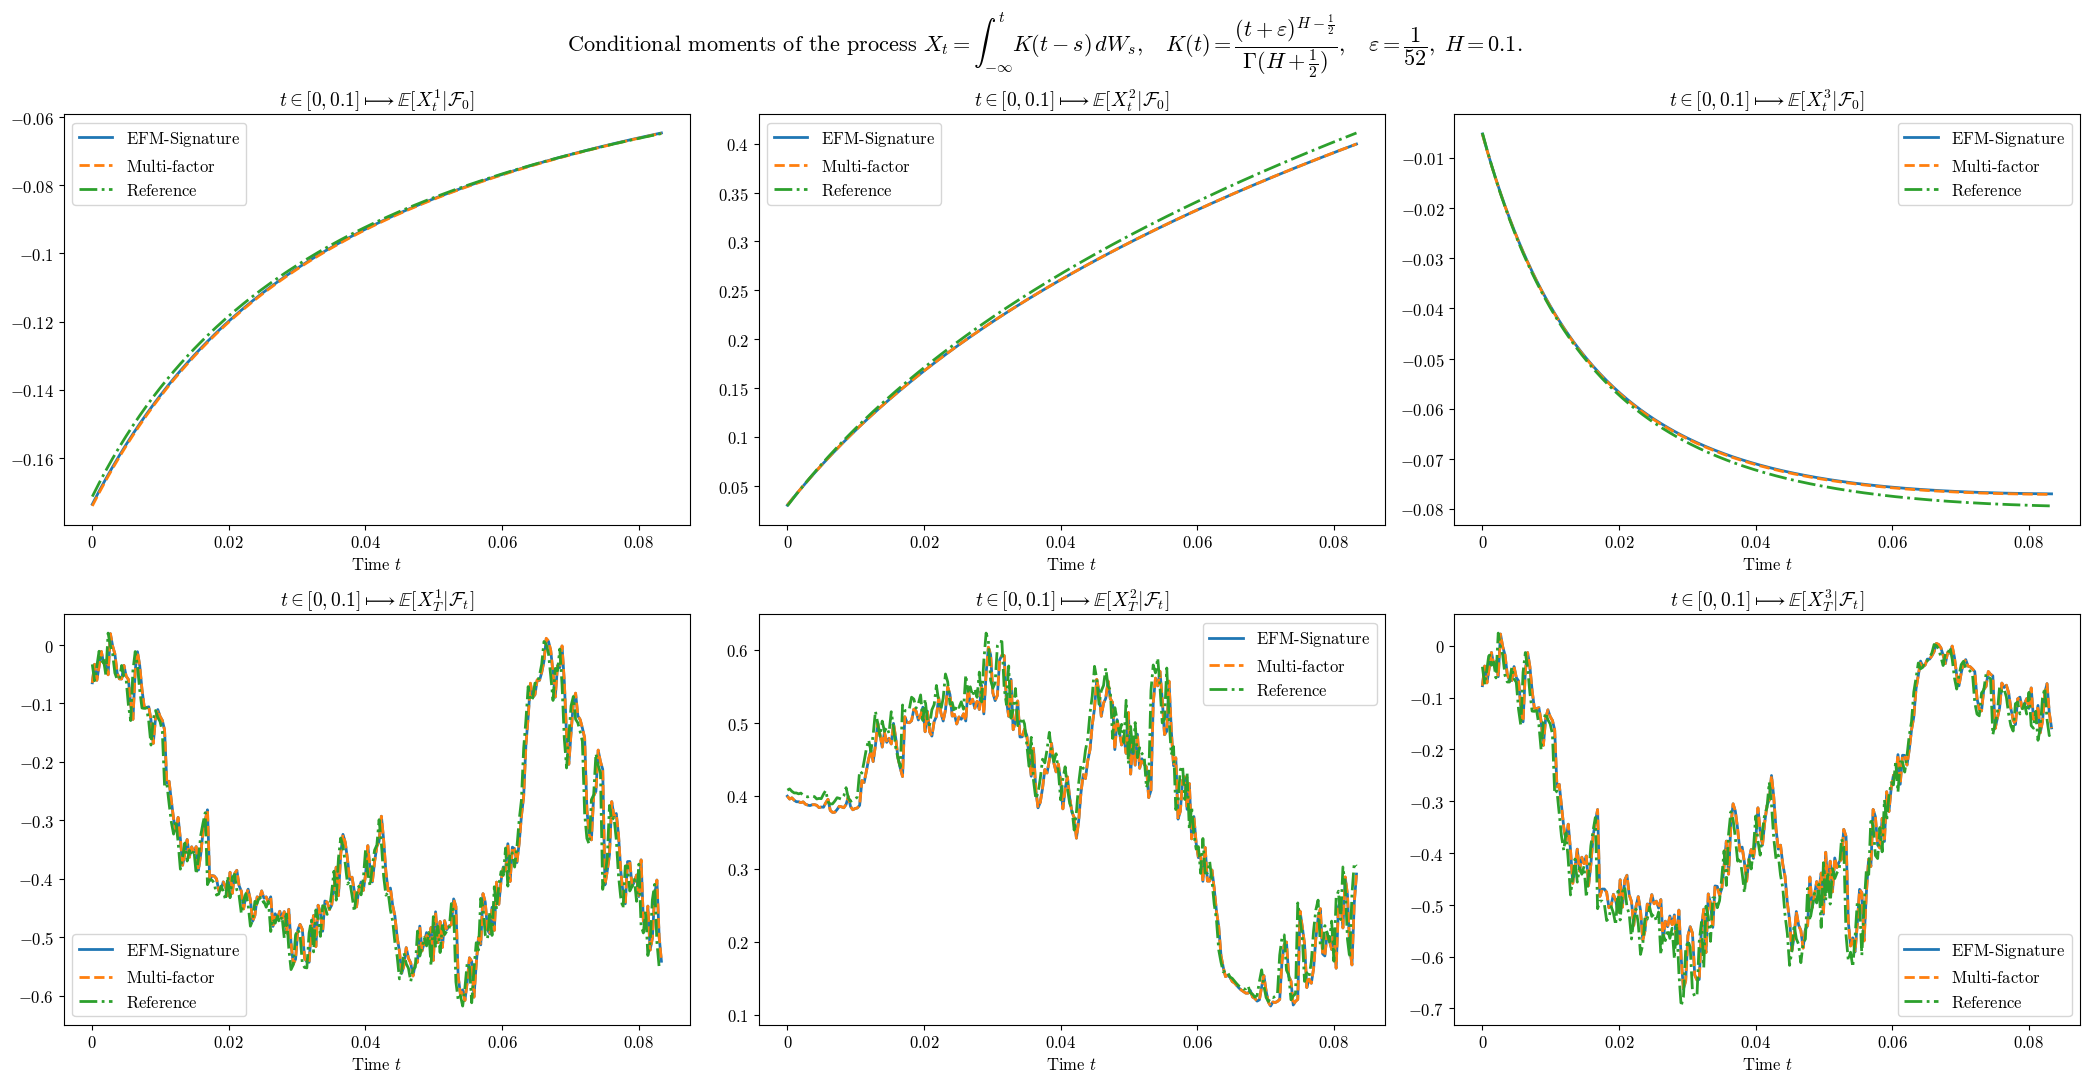

In [25]:
fig, ax = plt.subplots(2, 3, figsize=(21, 11))
ax = ax.flatten()
for i in range(3) : 
    ax[i].plot(t_main, moments[i], lw=2, color="tab:blue", label=r"$\text{EFM-Signature}$")
    ax[i+3].plot(t_main, conditional_moments[i], lw=2, color="tab:blue", label=r"$\text{EFM-Signature}$")
    ax[i].set_title(r"$t\in [0, 0.1]\longmapsto \mathbb{E}[$" + fr"$X_t^{i+1}$" + r"$|\mathcal{F}_0]$", fontsize=14)
    ax[i+3].set_title(r"$t\in [0, 0.1]\longmapsto \mathbb{E}[$" + fr"$X_T^{i+1}$" + r"$|\mathcal{F}_t]$", fontsize=14)

ax[0].plot(t_main, E_X_1_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")
ax[1].plot(t_main, E_X_2_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")
ax[2].plot(t_main, E_X_3_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")

ax[0].plot(t_main, E_X_t_given_F0, linestyle="-.", lw=2, color="tab:green", label=r"$\text{Reference}$")
ax[1].plot(t_main, E_X_2_exact, linestyle="-.", lw=2, color="tab:green", label=r"$\text{Reference}$")
ax[2].plot(t_main, E_X_3_exact, linestyle="-.", lw=2, color="tab:green", label=r"$\text{Reference}$")

ax[3].plot(t_main, E_X_1_t_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")
ax[4].plot(t_main, E_X_2_t_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")
ax[5].plot(t_main, E_X_3_t_multifactor, "--", lw=2, color="tab:orange", label=r"$\text{Multi-factor}$")

ax[3].plot(t_main, E_X_1_t_exact, linestyle="-.", lw=2, color="tab:green", label=r"$\text{Reference}$")
ax[4].plot(t_main, E_X_2_t_exact, linestyle="-.", lw=2, color="tab:green", label=r"$\text{Reference}$")
ax[5].plot(t_main, E_X_3_t_exact, linestyle="-.", lw=2, color="tab:green", label=r"$\text{Reference}$")

for i in range(6) : 
    ax[i].tick_params(axis='both', labelsize=12) 
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(fontsize=12)

fig.suptitle(r"$\text{Conditional moments of the process }X_t = \int_{-\infty}^t K(t-s)\, dW_s,\quad K(t) = \dfrac{(t+\varepsilon)^{H-\frac{1}{2}}}{\Gamma(H+\frac{1}{2})},\quad$"
             r"$\varepsilon = \dfrac{1}{52},\; H = 0.1.$", fontsize=16)
    
plt.tight_layout()
plt.show()